In [1]:
import torch
from torch import nn, optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime
import numpy as np
from collections import OrderedDict
from google.colab import output
output.enable_custom_widget_manager()

from IPython.display import display
import numpy as np
import torch
import matplotlib.pyplot as plt


import torch

# Define the device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")


Using device: cuda


In [2]:
!pip install ipycanvas
from ipycanvas import Canvas, hold_canvas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.0/143.0 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 66.6 MB/s eta 0:00:00


In [3]:
!pip install ipympl
!pip install ipycanvas


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.0/519.0 kB 21.0 MB/s eta 0:00:00


In [4]:
training_set = datasets.MNIST(root = './data', train=True, download=True, transform= transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: x.view(-1))]))
test_set = datasets.MNIST(root = './data', train=False, download=True, transform= transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: x.view(-1))]))

training_loader = torch.utils.data.DataLoader(training_set, batch_size = 4, shuffle=True, num_workers = 2)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=4, shuffle=False, num_workers=2)

100%|██████████| 9.91M/9.91M [00:00<00:00, 12.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 344kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.18MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.4MB/s]


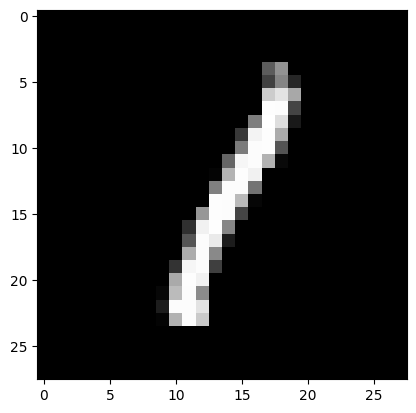

In [5]:
plt.imshow(test_set[202][0].reshape(28, 28), cmap='gray')

In [6]:
from typing import OrderedDict
import torch.nn as nn

class Autoencoder(nn.Module):
    def __init__(self, layers, activation):
        super(Autoencoder, self).__init__()
        encoder_layers = []

        # Encoder
        for i in range(len(layers) - 1):
            encoder_layers.append(('linear{}'.format(i), nn.Linear(layers[i], layers[i + 1])))
            if i != len(layers) - 2:
                encoder_layers.append(('activation{}'.format(i), activation()))

        # Decoder (reverse layers)
        decoder_layers = []
        decoder_layers_config = layers[::-1]
        for i in range(len(decoder_layers_config) - 1):
            decoder_layers.append(('linear{}'.format(i), nn.Linear(decoder_layers_config[i], decoder_layers_config[i + 1])))

            # Add activation except the last layer
            if i < len(layers) - 2:
                decoder_layers.append(('activation{}'.format(i), activation()))
            else:
                # Last layer → sigmoid for normalized [0,1] images
                decoder_layers.append(('output_activation', nn.Sigmoid()))

        self.encoder = nn.Sequential(OrderedDict(encoder_layers))
        self.decoder = nn.Sequential(OrderedDict(decoder_layers))

    def forward(self, x):
        x = x.view(-1, 28*28)
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded


Autoencoder([28*28, 256, 128, 64, 32, 16, 10], nn.ReLU)

Autoencoder(
  (encoder): Sequential(
    (linear0): Linear(in_features=784, out_features=256, bias=True)
    (activation0): ReLU()
    (linear1): Linear(in_features=256, out_features=128, bias=True)
    (activation1): ReLU()
    (linear2): Linear(in_features=128, out_features=64, bias=True)
    (activation2): ReLU()
    (linear3): Linear(in_features=64, out_features=32, bias=True)
    (activation3): ReLU()
    (linear4): Linear(in_features=32, out_features=16, bias=True)
    (activation4): ReLU()
    (linear5): Linear(in_features=16, out_features=10, bias=True)
  )
  (decoder): Sequential(
    (linear0): Linear(in_features=10, out_features=16, bias=True)
    (activation0): ReLU()
    (linear1): Linear(in_features=16, out_features=32, bias=True)
    (activation1): ReLU()
    (linear2): Linear(in_features=32, out_features=64, bias=True)
    (activation2): ReLU()
    (linear3): Linear(in_features=64, out_features=128, bias=True)
    (activation3): ReLU()
    (linear4): Linear(in_features

In [7]:
def training_run(layers, activation, EPOCHS):
  model = Autoencoder(layers, activation)
  loss_function = nn.MSELoss()
  optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-8)
  model.to('cuda')

  def train_one_epoch(epoch_index):
    running_loss = 0.
    last_loss = 0.

    for i, data in enumerate(training_loader):

      inputs, _ = data
      inputs = inputs.to('cuda') # Move inputs to GPU
      optimizer.zero_grad()
      outputs = model(inputs)
      loss = loss_function(outputs, inputs)
      loss.backward()
      optimizer.step()

      running_loss += loss.item()

      if i % 1000 == 999:
        last_loss = running_loss / 1000
        print('   batch {} loss: {}'.format(i + 1, last_loss))
        tb_x = epoch_index * len(training_loader) + i + 1
        running_loss = 0
    return last_loss

  best_vloss = 1_000_000

  for epoch in range(EPOCHS):

    print('EPOCH {}:'.format(epoch + 1))

    model.train(True)
    train_one_epoch(epoch)
    model.train(False)

  return model



In [8]:
def visualize_inference(model, n_example):

  # Select an example image from the test set
  test_image, _ = test_set[n_example]

  # Move the image to the same device as the model
  test_image = test_image.to('cuda')

  # Perform inference with the model
  model.eval() # Set the model to evaluation mode
  with torch.no_grad(): # Disable gradient calculation
    reconstructed_image = model(test_image)

  # Move the reconstructed image back to CPU and reshape it to 28x28
  reconstructed_image = reconstructed_image.cpu().view(28, 28)
  test_image = test_image.cpu().view(28, 28)

  # Display the original and reconstructed images
  fig, axes = plt.subplots(1, 2, figsize=(10, 5))
  axes[0].imshow(test_image.numpy(), cmap='gray')
  axes[0].set_title('Original Image')
  axes[0].axis('off')

  axes[1].imshow(reconstructed_image.numpy(), cmap='gray')
  axes[1].set_title('Reconstructed Image')
  axes[1].axis('off')

  plt.show()

In [9]:
EPOCHS = 1
model = training_run([28*28, 256, 128, 64, 10], nn.ReLU , EPOCHS)

EPOCH 1:
   batch 1000 loss: 0.06111588213033974
   batch 2000 loss: 0.04630091914720833
   batch 3000 loss: 0.03928601871524006
   batch 4000 loss: 0.03533132996968925
   batch 5000 loss: 0.03386270963586867
   batch 6000 loss: 0.03127162229362875
   batch 7000 loss: 0.029515074687078594
   batch 8000 loss: 0.02818287684954703
   batch 9000 loss: 0.027639216057024896
   batch 10000 loss: 0.027258925849571822
   batch 11000 loss: 0.025844896369613707
   batch 12000 loss: 0.02572905542049557
   batch 13000 loss: 0.02559026623237878
   batch 14000 loss: 0.025045957786962388
   batch 15000 loss: 0.024261979665607215


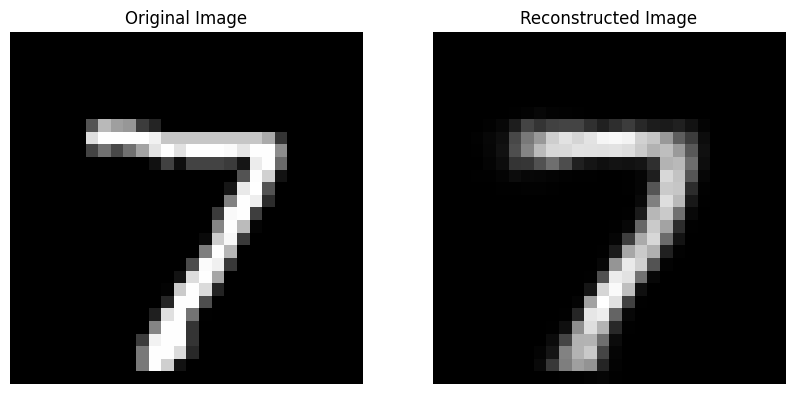

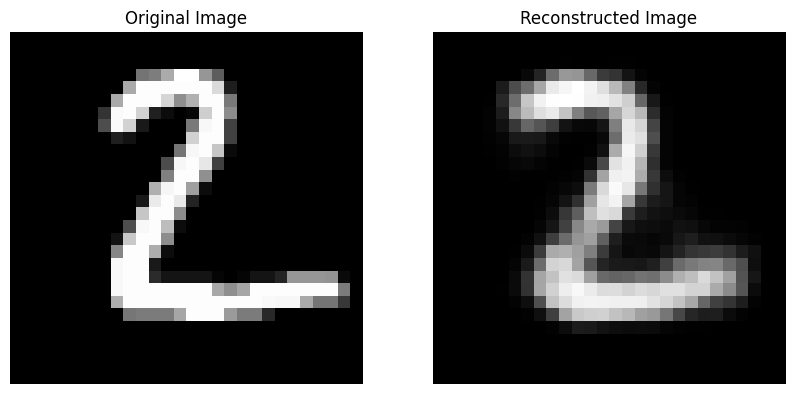

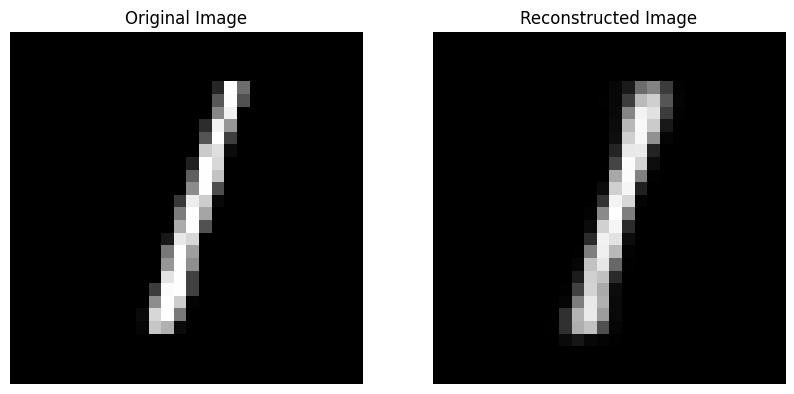

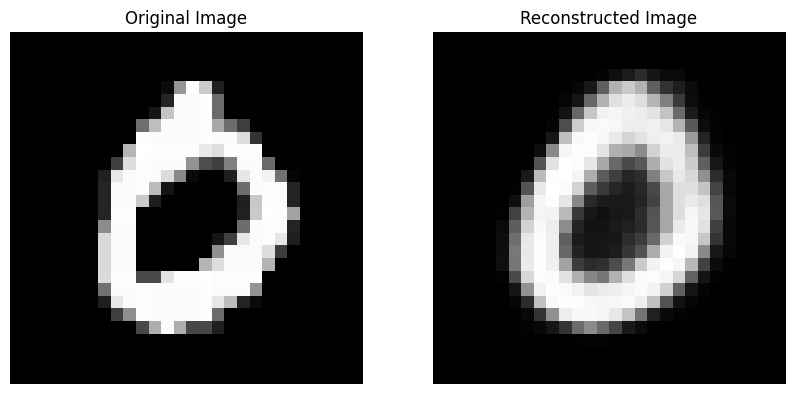

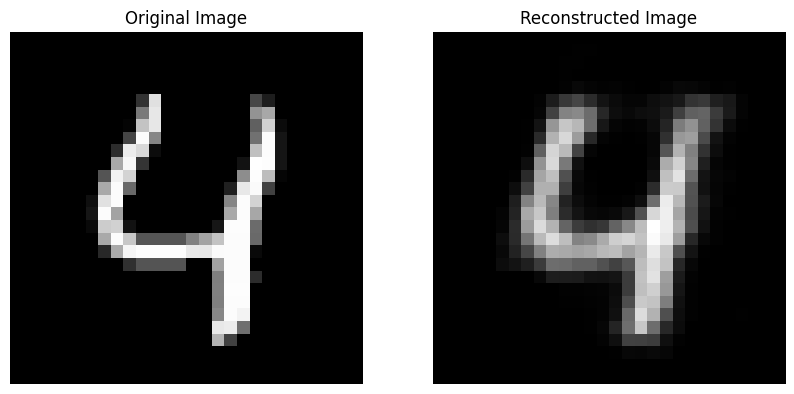

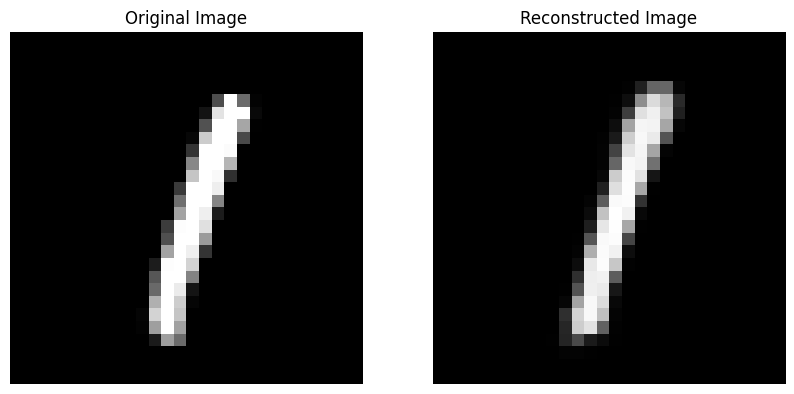

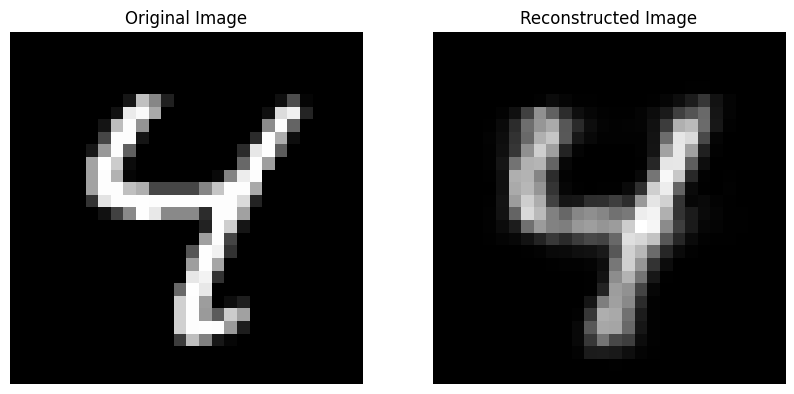

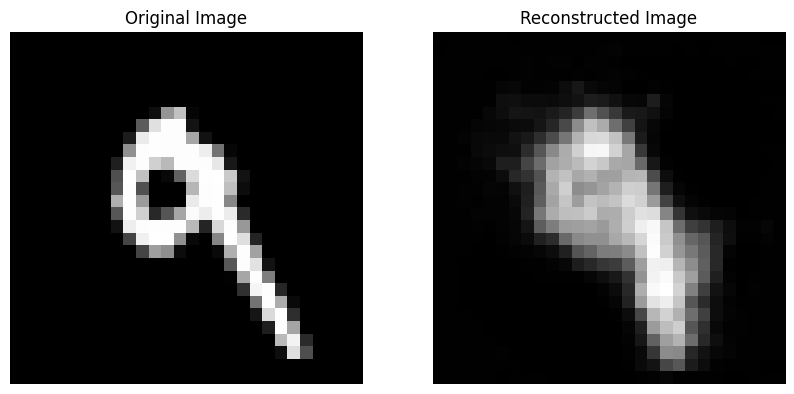

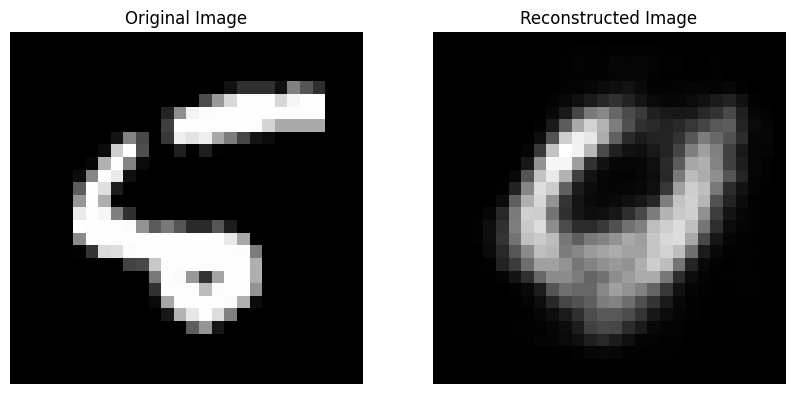

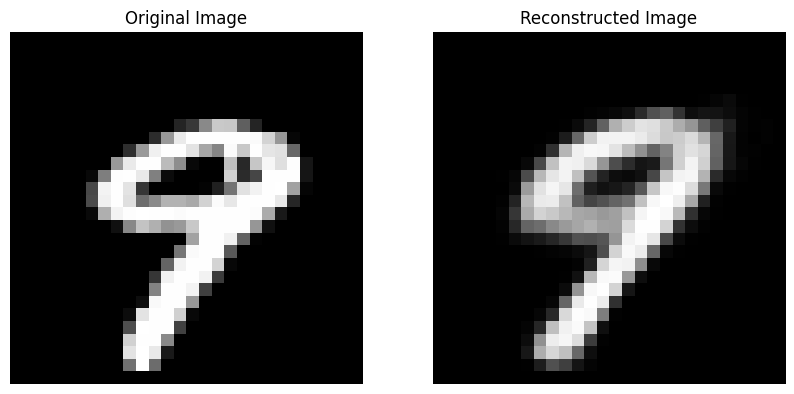

In [10]:
for i in range(10):
  visualize_inference(model, i)

In [11]:
import torch
import numpy as np
import matplotlib.pyplot as plt

n = 10

# Importa los widgets necesarios, incluyendo Button y interactive_output
from ipywidgets import interactive_output, FloatSlider, VBox, HBox, Button
from IPython.display import display

# --- Configuración (Asegúrate de que 'n', 'model' y 'device' estén definidos) ---
# n = 10
# device = 'cuda' if torch.cuda.is_available() else 'cpu'
# model.to(device) # Asegúrate de que tu modelo esté en el 'device'
# ---

# Tu función original para actualizar la imagen
# (Modificada para usar la variable 'device' por seguridad)
def update_image(**kwargs):
    input_vector = np.array([kwargs[f'component_{i}'] for i in range(n)])

    # Convierte a tensor y mueve al 'device'
    input_tensor = torch.from_numpy(input_vector).float().to(device)

    # Genera la salida del modelo
    # (Asegúrate de que 'model' esté definido globalmente y en el 'device')
    out = model.decoder(input_tensor)
    test_image = out.cpu().view(28, 28)

    # Muestra la imagen
    plt.figure(figsize=(6, 6))
    plt.imshow(test_image.detach().numpy(), cmap='gray')
    plt.title('Generated Image')
    plt.axis('off')
    plt.show()

    print(f"Current vector: {input_vector}")

# --- 1. Crear los Sliders ---
sliders = {}
for i in range(10):
    initial_value = 100.0 if i in [3, 9] else 0.0
    sliders[f'component_{i}'] = FloatSlider(
        value=initial_value,
        min= -10.0,
        max= 10.0,
        step= 0.01,
        description=f'Neurona {i + 1}:',
        style={'description_width': 'initial'},
        layout={'width': '400px'}
    )

# --- 2. Crear el Botón de Reseteo y su Función (Callback) ---
# Crea el botón
reset_button = Button(
    description='Resetear a Cero',
    button_style='warning', # 'warning' es un color naranja
    icon='refresh'          # Icono de refrescar
)

# Define qué pasa cuando se hace clic en el botón
def on_reset_button_clicked(b):
    # Itera sobre todos los sliders y pone su valor a 0.0
    for i in range(n):
        sliders[f'component_{i}'].value = 0.0

# Vincula la función 'on_reset_button_clicked' al evento 'on_click' del botón
reset_button.on_click(on_reset_button_clicked)

# --- 3. Organizar la Interfaz de Usuario (Layout) ---
# (Esto reemplaza tu llamada a 'interact(...)' y tu función 'create_organized_sliders')

# 1. Vincula la función 'update_image' a los 'sliders'.
#    Esto crea el área de salida del gráfico (el plot).
plot_output = interactive_output(update_image, sliders)

# 2. Organiza los sliders en dos columnas (usando tu lógica)
left_column = VBox([sliders[f'component_{i}'] for i in range(5)])
# --- LÍNEA CORREGIDA ---
right_column = VBox([sliders[f'component_{i}'] for i in range(5, 10)])
slider_layout = HBox([left_column, right_column])

# 3. Agrupa todos los controles (sliders + botón)
controls = VBox([slider_layout, reset_button])

# 4. Crea la UI final: Controles a la izquierda, gráfico a la derecha
ui = HBox([controls, plot_output])

# --- 4. Mostrar la Interfaz de Usuario ---
# Simplemente muestra el objeto 'ui' que acabamos de construir.
display(ui)

In [12]:
import torch
import torch.nn.functional as F

# Assuming 'model' and 'test_loader' are already defined and model is on 'device'
# n_code = 10 (from your previous code)
# n_digits = 10 (for digits 0-9)

n_code = 10
n_digits = 10

# Step 1: Create lists to store activations for each digit
# all_activations[0] will hold all code vectors for digit '0'
# all_activations[1] will hold all code vectors for digit '1', etc.
all_activations = [[] for _ in range(n_digits)]

# Step 2: Loop through the dataset and collect activations
print("Collecting activations from the test set...")
model.eval()  # Set model to evaluation mode
with torch.no_grad():  # We don't need to track gradients
    for data, labels in test_loader:
        data = data.to(device)

        # Pass data through the ENCODER to get the code vector
        # Note: We use .encoder() here, not .decoder()
        # Assumes your encoder outputs the latent vector directly
        # If it's a VAE, you'd use z = model.encoder(data)[0] or model.reparameterize(*model.encoder(data))
        code_vectors = model.encoder(data)

        # Move to CPU for list appending
        code_vectors_cpu = code_vectors.cpu()
        labels_cpu = labels.cpu()

        # Group activations by their label
        for i in range(len(labels_cpu)):
            label = labels_cpu[i].item()
            activation = code_vectors_cpu[i]

            # We take the absolute value, as "importance" is about
            # magnitude, not positive/negative sign.
            all_activations[label].append(activation.abs())

print("Collection complete.")

# Step 3: Calculate the average activation for each digit
# This will result in a 10x10 tensor
avg_activations_list = []
for digit in range(n_digits):
    if len(all_activations[digit]) > 0:
        # Stack all activations for this digit and find the mean
        # This converts our list of (10,) tensors into a (N, 10) tensor
        # and then finds the mean along dim 0 to get a (10,) tensor
        avg_vec = torch.stack(all_activations[digit]).mean(dim=0)
        avg_activations_list.append(avg_vec)
    else:
        # Handle case where a digit might be missing (unlikely for MNIST)
        avg_activations_list.append(torch.zeros(n_code))

# Stack the 10 average vectors into a single 10x10 matrix
avg_activations_matrix = torch.stack(avg_activations_list)
# avg_activations_matrix[3] is the average activation for digit '3'


# Step 4: Normalize each row (each digit's vector) to a 0-1 scale
importance_matrix = torch.zeros_like(avg_activations_matrix)

for i in range(n_digits):
    row = avg_activations_matrix[i]
    min_val = row.min()
    max_val = row.max()

    # Apply min-max scaling: (value - min) / (max - min)
    # Add a small epsilon to avoid division by zero if all values are the same
    normalized_row = (row - min_val) / (max_val - min_val + 1e-6)
    importance_matrix[i] = normalized_row



Collection complete.


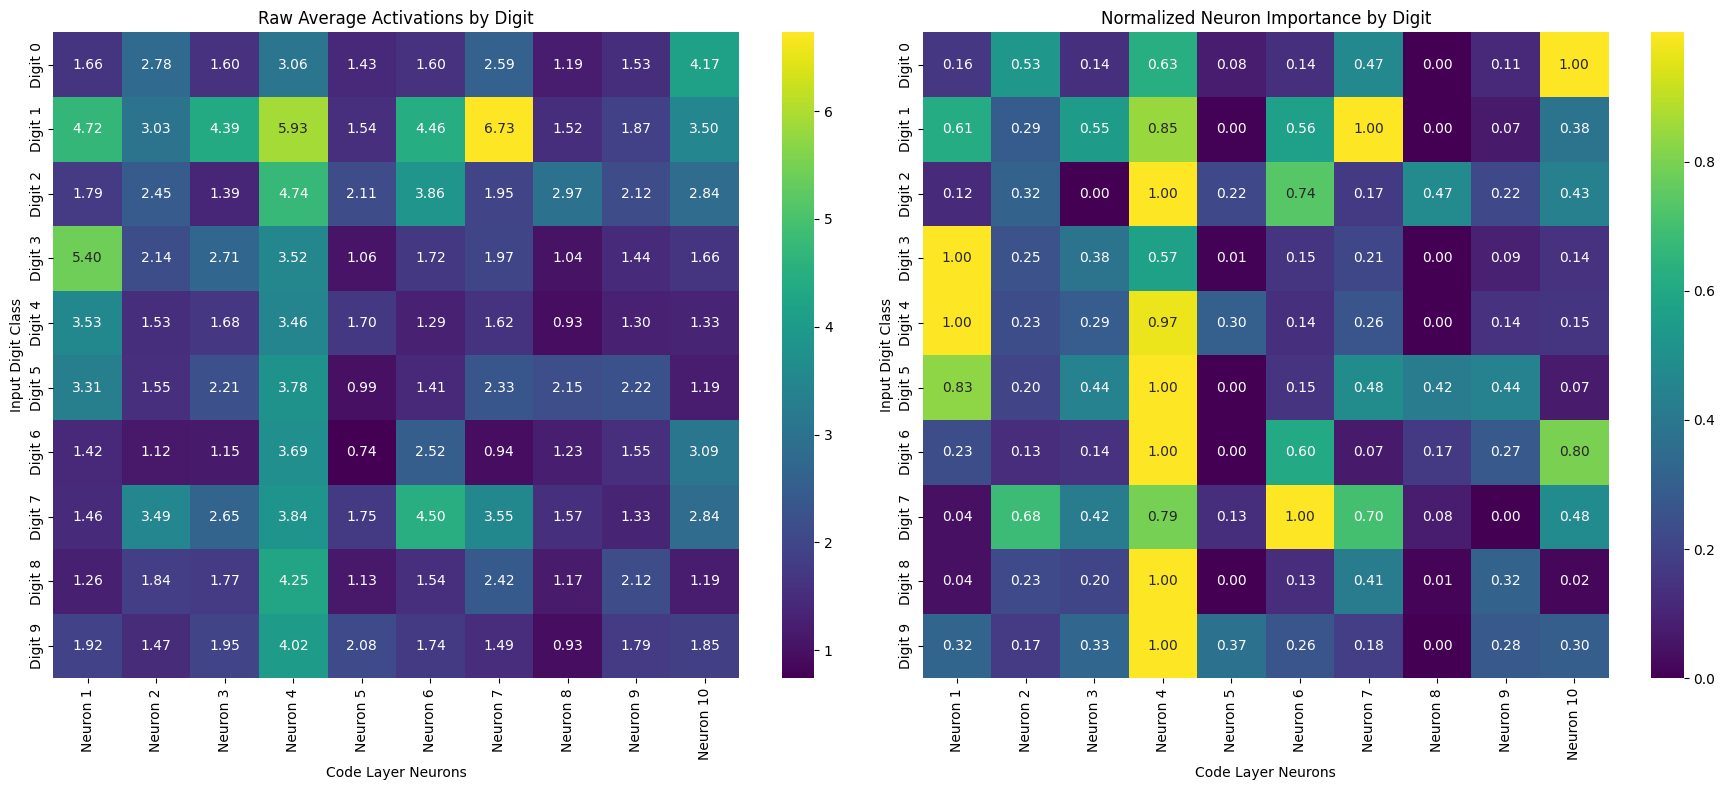

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# --- Left: raw activations ---
sns.heatmap(
    avg_activations_matrix.numpy(),
    annot=True,
    fmt=".2f",
    cmap='viridis',
    xticklabels=[f"Neuron {i + 1}" for i in range(n_code)],
    yticklabels=[f"Digit {i}" for i in range(n_digits)],
    ax=axes[0]
)
axes[0].set_title("Raw Average Activations by Digit")
axes[0].set_xlabel("Code Layer Neurons")
axes[0].set_ylabel("Input Digit Class")

# --- Right: normalized activations ---
sns.heatmap(
    importance_matrix.numpy(),
    annot=True,
    fmt=".2f",
    cmap='viridis',
    xticklabels=[f"Neuron {i + 1}" for i in range(n_code)],
    yticklabels=[f"Digit {i}" for i in range(n_digits)],
    ax=axes[1]
)
axes[1].set_title("Normalized Neuron Importance by Digit")
axes[1].set_xlabel("Code Layer Neurons")
axes[1].set_ylabel("Input Digit Class")

plt.tight_layout()
plt.show()


## Consideremos un modelo más pequeño

In [14]:
EPOCHS = 1
model_2 = training_run([28*28, 256, 128, 64, 3], nn.ReLU , EPOCHS)

EPOCH 1:
   batch 1000 loss: 0.06032933994755149
   batch 2000 loss: 0.047763097340241076
   batch 3000 loss: 0.04216062089055777
   batch 4000 loss: 0.04038341765850782
   batch 5000 loss: 0.03853948315884918
   batch 6000 loss: 0.03732348301075399
   batch 7000 loss: 0.03741450641769916
   batch 8000 loss: 0.0366435521133244
   batch 9000 loss: 0.03557462783809751
   batch 10000 loss: 0.03579320196341723
   batch 11000 loss: 0.03540742370486259
   batch 12000 loss: 0.035297946668229996
   batch 13000 loss: 0.03505148437991738
   batch 14000 loss: 0.03478823667485267
   batch 15000 loss: 0.034730239761061966


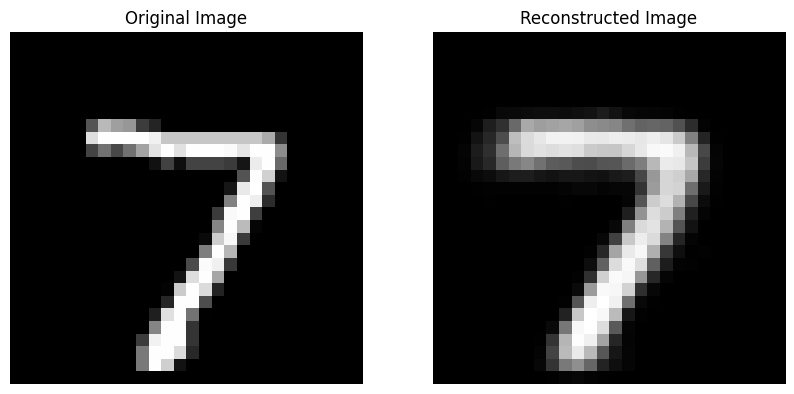

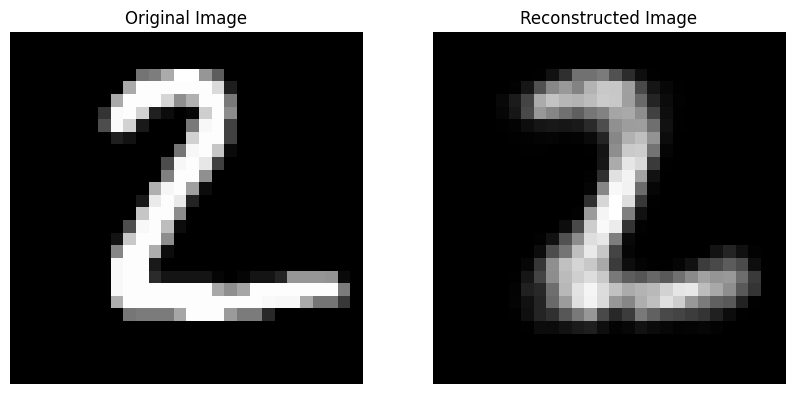

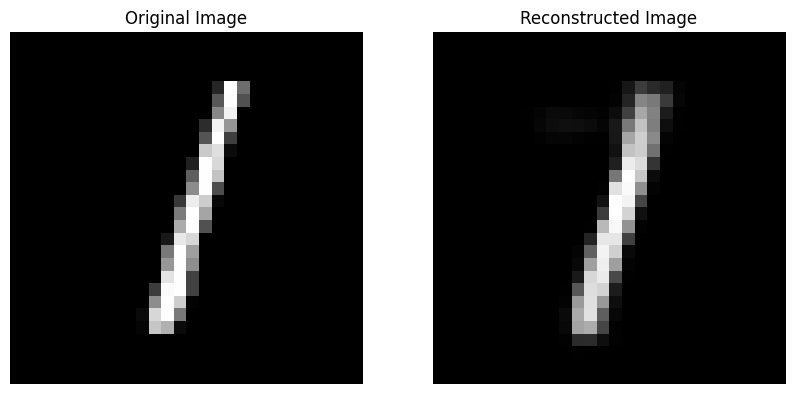

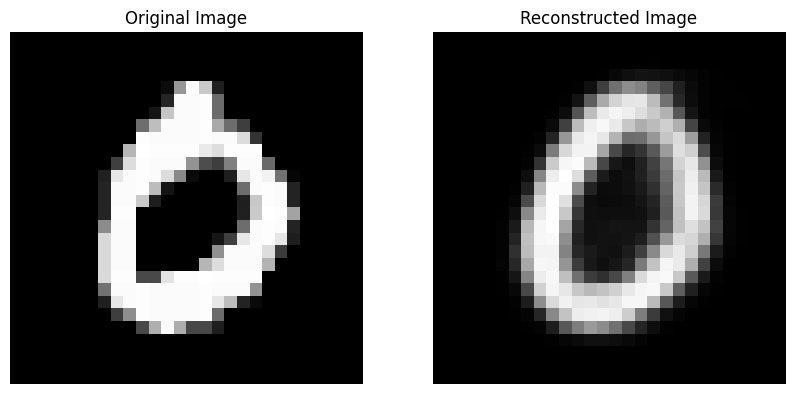

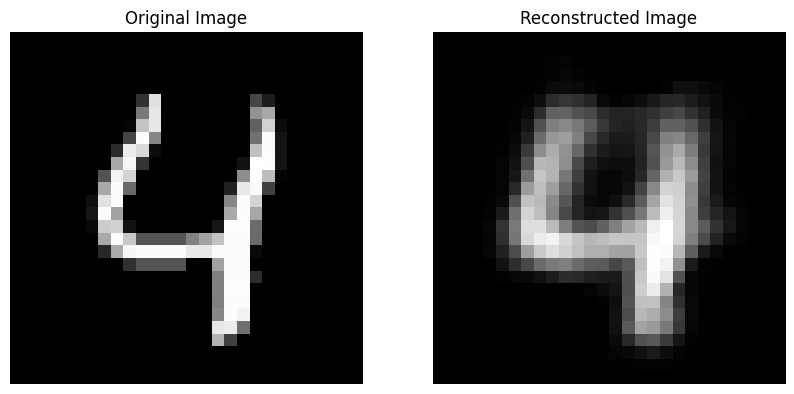

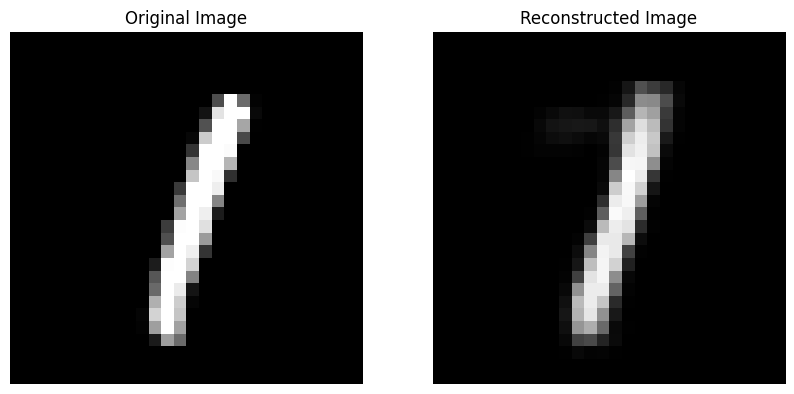

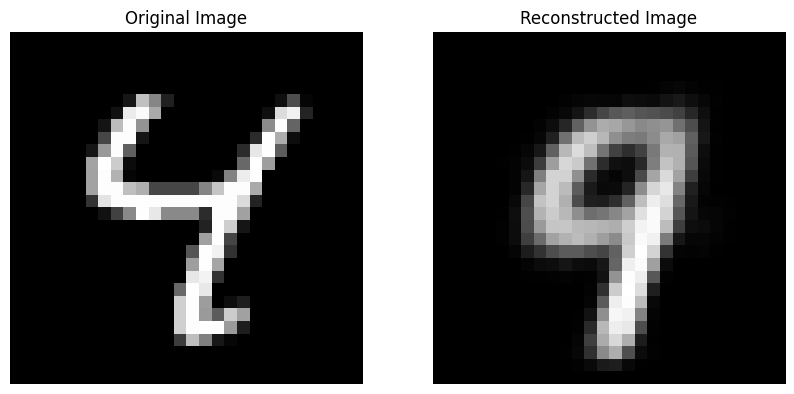

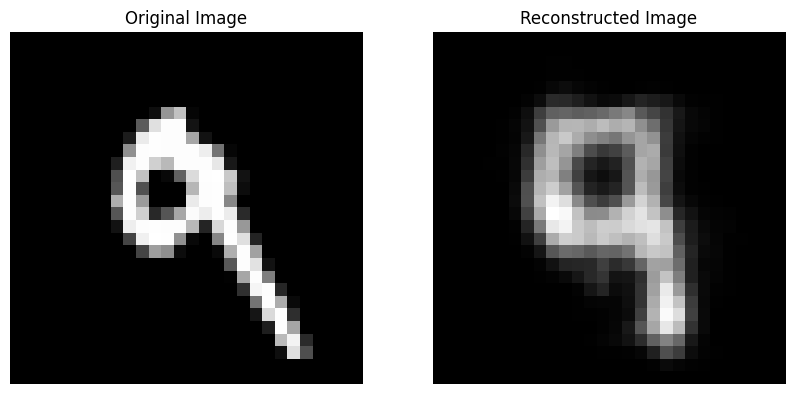

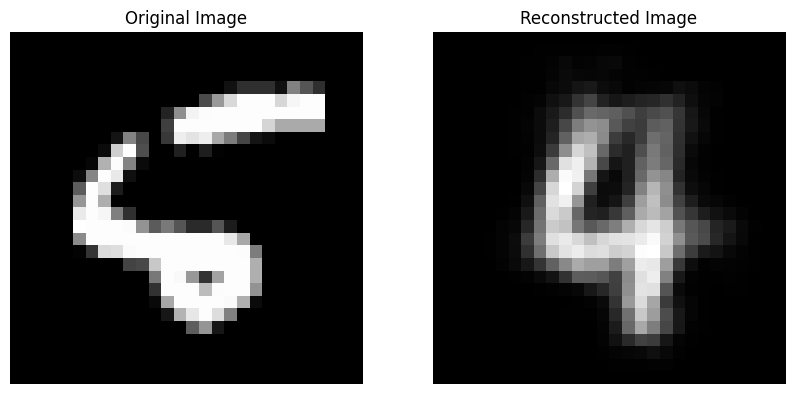

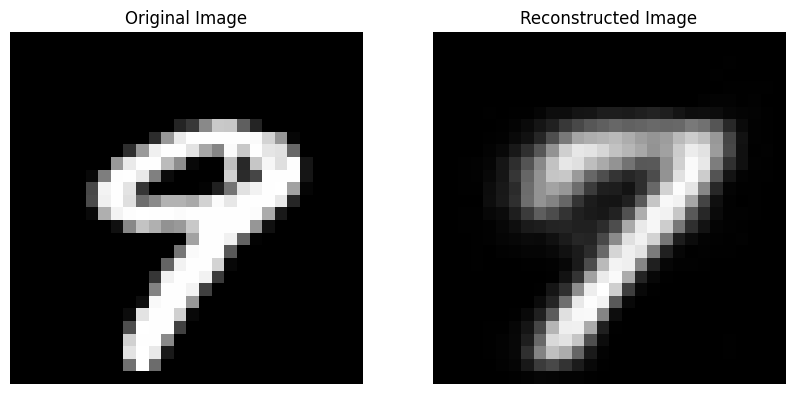

In [15]:
for i in range(10):
  visualize_inference(model_2, i)

In [16]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

# --- Variables Clave ---
n_code = 3               # <-- ¡El cambio principal!
n_digits = 10            # (Esto sigue igual, 0-9)
target_model = model_2   # <-- Usamos tu nuevo modelo

# --- Paso 1: Crear listas para almacenar las activaciones ---
all_activations = [[] for _ in range(n_digits)]

# --- Paso 2: Recorrer el dataset y recolectar activaciones ---
print(f"Recolectando activaciones del modelo con {n_code} neuronas...")
target_model.eval()  # Poner el modelo en modo de evaluación
with torch.no_grad():
    for data, labels in test_loader:
        data = data.to(device)

        # Pasa los datos por el ENCODER de tu 'model_2'
        code_vectors = target_model.encoder(data)

        # Mueve a la CPU para guardarlos en la lista
        code_vectors_cpu = code_vectors.cpu()
        labels_cpu = labels.cpu()

        # Agrupa las activaciones por su etiqueta
        for i in range(len(labels_cpu)):
            label = labels_cpu[i].item()
            activation = code_vectors_cpu[i]

            # Usamos el valor absoluto para medir la "magnitud" o "importancia"
            all_activations[label].append(activation.abs())

print("Recolección completa.")

# --- Paso 3: Calcular la activación promedio para cada dígito ---
avg_activations_list = []
for digit in range(n_digits):
    if len(all_activations[digit]) > 0:
        # Apila todas las activaciones y calcula la media
        avg_vec = torch.stack(all_activations[digit]).mean(dim=0)
        avg_activations_list.append(avg_vec)
    else:
        # En caso de que falte un dígito (poco probable)
        avg_activations_list.append(torch.zeros(n_code))

# Apila los vectores promedio en una matriz (será de 10x3)
avg_activations_matrix = torch.stack(avg_activations_list)


# --- Paso 4: Normalizar cada fila (cada dígito) a una escala 0-1 ---
importance_matrix_3d = torch.zeros_like(avg_activations_matrix)

for i in range(n_digits):
    row = avg_activations_matrix[i]
    min_val = row.min()
    max_val = row.max()

    # Escalado Min-Max: (valor - min) / (max - min)
    normalized_row = (row - min_val) / (max_val - min_val + 1e-6)
    importance_matrix_3d[i] = normalized_row

print("Matriz de importancia calculada.")

Recolectando activaciones del modelo con 3 neuronas...
Recolección completa.
Matriz de importancia calculada.


In [17]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Importa los widgets necesarios
from ipywidgets import interactive_output, FloatSlider, VBox, HBox, Button, Output
from IPython.display import display

# --- 0. Configuración ---
# (Asume que 'model_2', 'device', 'importance_matrix_3d',
# 'avg_activations_matrix' y 'test_loader' ya existen)
n_code = 3
n_digits = 10

# --- 1. Definir los Sliders y Botón para n=3 ---

# Diccionario para los 3 nuevos sliders
sliders_3d = {}
for i in range(n_code):
    sliders_3d[f'component_3d_{i}'] = FloatSlider(
        value=0.0, # Empezar en cero por defecto
        min= -4.0,
        max= 4.0,
        step= 0.01,
        description=f'Neurona {i + 1}:', # Nombres 1, 2, 3
        style={'description_width': 'initial'},
        layout={'width': '300px'}
    )

# Botón de reseteo para los 3 sliders
reset_button_3d = Button(
    description='Resetear a Cero',
    button_style='warning',
    icon='refresh'
)

# Función de callback para el botón
def on_reset_3d_clicked(b):
    for i in range(n_code):
        sliders_3d[f'component_3d_{i}'].value = 0.0

# Vincular el botón
reset_button_3d.on_click(on_reset_3d_clicked)

# --- 2. Definir la Función de Actualización para n=3 ---

# Esta función usa 'model_2' y espera 3 componentes
def update_image_3d(**kwargs):
    # Crea el vector de entrada desde los 3 sliders
    input_vector = np.array([kwargs[f'component_3d_{i}'] for i in range(n_code)])

    input_tensor = torch.from_numpy(input_vector).float().to(device)

    # --- ¡IMPORTANTE: Usa model_2.decoder! ---
    out = model_2.decoder(input_tensor)
    test_image = out.cpu().view(28, 28)

    # Muestra la imagen
    plt.figure(figsize=(6, 6))
    plt.imshow(test_image.detach().numpy(), cmap='gray')
    plt.title('Imagen Generada (3 Neuronas)')
    plt.axis('off')
    plt.show()

    print(f"Vector actual (3D): {input_vector}")


# --- 3. Construir la Interfaz de Usuario (UI) ---

# --- Panel 1 (Izquierda): Heatmap de Importancia ---
# Usamos un 'Output' widget para "capturar" el gráfico
importance_heatmap_output = Output()

# Dibuja el heatmap DENTRO del widget 'importance_heatmap_output'
with importance_heatmap_output:
    plt.figure(figsize=(6, 8)) # Tamaño ajustado para 10x3
    sns.heatmap(
        importance_matrix_3d.numpy(),
        annot=True,
        fmt=".2f",
        cmap='viridis',
        xticklabels=[f"Neurona {i+1}" for i in range(n_code)],
        yticklabels=[f"Dígito {i}" for i in range(n_digits)]
    )
    plt.title(f"Importancia (Capa = {n_code})")
    plt.xlabel("Neuronas")
    plt.ylabel("Dígito")
    plt.show()

# --- Panel 2 (Centro): Heatmap de Activación Promedio ---
# Creamos un SEGUNDO widget 'Output'
avg_heatmap_output = Output()

# Dibuja el heatmap de promedios DENTRO de este nuevo widget
with avg_heatmap_output:
    plt.figure(figsize=(6, 8)) # Mismo tamaño que antes
    sns.heatmap(
        avg_activations_matrix.numpy(),
        annot=True,
        fmt=".2f",          # Mantenemos 2 decimales
        cmap='viridis',     # Mantenemos el mismo color
        xticklabels=[f"Neurona {i+1}" for i in range(n_code)],
        yticklabels=[f"Dígito {i}" for i in range(n_digits)]
    )
    plt.title(f"Activación Promedio (Capa = {n_code})") # <-- Título actualizado
    plt.xlabel("Neuronas")
    plt.ylabel("Dígito")
    plt.show()


# --- Panel 3 (Derecha): Sliders + Imagen Generada ---

# 1. Apila los sliders y el botón verticalmente
controls_3d = VBox(
    [sliders_3d[f'component_3d_{i}'] for i in range(n_code)] + [reset_button_3d]
)

# 2. Vincula la función 'update_image_3d' a los sliders 'sliders_3d'
plot_output_3d = interactive_output(update_image_3d, sliders_3d)

# 3. Apila los controles y la imagen generada (para formar el panel derecho)
#    (Controles arriba, imagen abajo)
right_pane = VBox([controls_3d, plot_output_3d])


# --- 4. Combinar Paneles y Mostrar ---

# HBox final con los TRES paneles en orden horizontal
full_ui = HBox([importance_heatmap_output, avg_heatmap_output, right_pane])

# Muestra la interfaz de usuario completa
display(full_ui)

In [18]:
import torch
import numpy as np
import plotly.graph_objects as go
from IPython.display import display

# --- 1. Configurar los "Hooks" (Espías) en model_2 ---

activations = {}

def get_activation(name):
    """Crea una función hook para capturar activaciones."""
    def hook(model, input, output):
        activations[name] = output.detach().cpu()
    return hook

# Asegúrate de que los hooks están en el modelo correcto: model_2
# Y asume que el codificador es un iterable (como nn.Sequential)
for i, encoder_layer in enumerate(model_2.encoder):
    encoder_layer.register_forward_hook(get_activation(f'encoder layer {i}'))

# ¡IMPORTANTE! Necesitamos el índice de la capa de código.
# Asumimos que es la ÚLTIMA capa del codificador.
# (Si tu encoder tiene 4 capas, sus índices son 0, 1, 2, 3. len=4, así que el índice es 3)
n_code_layer_index = len(model_2.encoder) - 1
print(f"Espiando la capa del codificador: {n_code_layer_index}")


# --- 2. Recolectar Activaciones de model_2 ---

# Inicializa 10 listas, una para cada dígito
X = [[] for _ in range(10)]
Y = [[] for _ in range(10)] # Para mantener un seguimiento, aunque no se use en el gráfico

print("Recolectando activaciones del dataset...")
model_2.eval() # Poner model_2 en modo de evaluación

# Procesar las primeras 5000 muestras
for j in range(10000):
    test_image, label = test_set[j]
    # Mueve la imagen al device y añade una dimensión de 'batch' (lote)
    test_image = test_image.to(device).unsqueeze(0)

    with torch.no_grad():
        # Ejecuta la inferencia en model_2
        # Esto disparará los hooks que acabamos de registrar
        reconstructed_image = model_2(test_image)

    # Obtiene la activación de la capa de código que nos interesa
    act = activations[f"encoder layer {n_code_layer_index}"]

    # .squeeze() elimina la dimensión extra del 'batch'
    features = act.squeeze().tolist()

    # Añade el vector de características (3D) a la lista del dígito correcto
    X[label].append(features)
    Y[label].append(label)

print("Recolección completa.")

# --- 3. Crear el Diccionario de Datos para Graficar ---

digit_datasets = {}
for digit in range(10):
    digit_datasets[digit] = {
        'activation_vectors': np.array(X[digit]),
        'labels': np.array(Y[digit])
    }

# Imprime un resumen de los datos recolectados
for digit, data in digit_datasets.items():
    print(f"Dígito {digit}: {len(data['activation_vectors'])} muestras, "
          f"Forma (Shape): {data['activation_vectors'].shape}")


# --- 4. Graficar con Plotly (Tu código, sin cambios) ---

# Define una lista de colores para cada dígito
colors = ['red', 'green', 'blue', 'cyan', 'magenta',
          'yellow', 'black', 'orange', 'purple', 'brown']

fig = go.Figure()

for digit, data in digit_datasets.items():
    activation_vectors = data['activation_vectors']

    # Asegúrate de que hay datos antes de intentar graficar
    if len(activation_vectors) > 0:
        fig.add_trace(go.Scatter3d(
            x=activation_vectors[:, 0], # Componente 1 (X)
            y=activation_vectors[:, 1], # Componente 2 (Y)
            z=activation_vectors[:, 2], # Componente 3 (Z)
            mode='markers',
            marker=dict(size=3, color=colors[digit]),
            name=f'Dígito {digit}'
        ))

fig.update_layout(
    title="Espacio de Activación 3D por Dígito (Modelo de 3 Neuronas)",
    scene=dict(
        xaxis_title="Neurona 1",
        yaxis_title="Neurona 2",
        zaxis_title="Neurona 3"
    ),
    width=900,
    height=700
)

fig.show()

Espiando la capa del codificador: 6
Recolectando activaciones del dataset...
Recolección completa.
Dígito 0: 980 muestras, Forma (Shape): (980, 3)
Dígito 1: 1135 muestras, Forma (Shape): (1135, 3)
Dígito 2: 1032 muestras, Forma (Shape): (1032, 3)
Dígito 3: 1010 muestras, Forma (Shape): (1010, 3)
Dígito 4: 982 muestras, Forma (Shape): (982, 3)
Dígito 5: 892 muestras, Forma (Shape): (892, 3)
Dígito 6: 958 muestras, Forma (Shape): (958, 3)
Dígito 7: 1028 muestras, Forma (Shape): (1028, 3)
Dígito 8: 974 muestras, Forma (Shape): (974, 3)
Dígito 9: 1009 muestras, Forma (Shape): (1009, 3)


In [19]:
# --- 5. Calcular y Graficar Vectores Promedio ---

# 5.a. Calcular el vector de activación promedio para cada dígito
average_vectors = {}
for digit, data in digit_datasets.items():
    if len(data['activation_vectors']) > 0:
        # Calcula la media de todas las activaciones para este dígito
        avg_vec = np.mean(data['activation_vectors'], axis=0)
        average_vectors[digit] = avg_vec
    else:
        # En caso de que no se hayan encontrado muestras (poco probable)
        average_vectors[digit] = np.array([0, 0, 0])

print("\nVectores de activación promedio:")
for digit, avg_vec in average_vectors.items():
    print(f"Dígito {digit}: {avg_vec}")

# 5.b. Crear la segunda gráfica 3D para los vectores promedio
fig_avg = go.Figure()

# Reutilizamos la misma lista de colores
colors = ['red', 'green', 'blue', 'cyan', 'magenta',
          'yellow', 'black', 'orange', 'purple', 'brown']

for digit, avg_vec in average_vectors.items():
    # Para dibujar una flecha desde (0,0,0) hasta (x,y,z),
    # simplemente trazamos una línea entre esos dos puntos.
    fig_avg.add_trace(go.Scatter3d(
        x=[0, avg_vec[0]],  # Coordenadas X: [inicio, fin]
        y=[0, avg_vec[1]],  # Coordenadas Y: [inicio, fin]
        z=[0, avg_vec[2]],  # Coordenadas Z: [inicio, fin]
        mode='lines+markers',
        line=dict(color=colors[digit], width=6), # Línea más gruesa
        marker=dict(size=4, color=colors[digit]), # Marcador en la punta
        name=f'Promedio Dígito {digit}'
    ))

# 5.c. Configurar el layout de la nueva gráfica
fig_avg.update_layout(
    title="Vectores de Activación Promedio por Dígito (Desde el Origen)",
    scene=dict(
        xaxis_title="Neurona 1",
        yaxis_title="Neurona 2",
        zaxis_title="Neurona 3",
        # Opcional: Asegurar que los ejes tengan un rango similar
        # aspectmode='cube'
    ),
    width=900,
    height=700
)

# 5.d. Mostrar la nueva gráfica
fig_avg.show()


Vectores de activación promedio:
Dígito 0: [-0.53354556 -3.29144316  5.35470248]
Dígito 1: [-0.10880759  3.46855747 -6.92162961]
Dígito 2: [ 0.90438512 -4.21700809 -2.79170433]
Dígito 3: [-2.67065482 -2.10560698  0.09136379]
Dígito 4: [0.34295426 1.26654346 0.39872432]
Dígito 5: [-0.87301229 -0.69641135  0.22835693]
Dígito 6: [ 0.23170549 -0.06542963  1.30948948]
Dígito 7: [ 1.89775437  4.61917201 -1.41136569]
Dígito 8: [-1.25891641 -0.49363982 -0.79159368]
Dígito 9: [0.21179223 1.5144022  0.06712133]


First layer weights shape: torch.Size([256, 784])

Saved 'first_layer_weights_ALL_256.png' to Colab files.


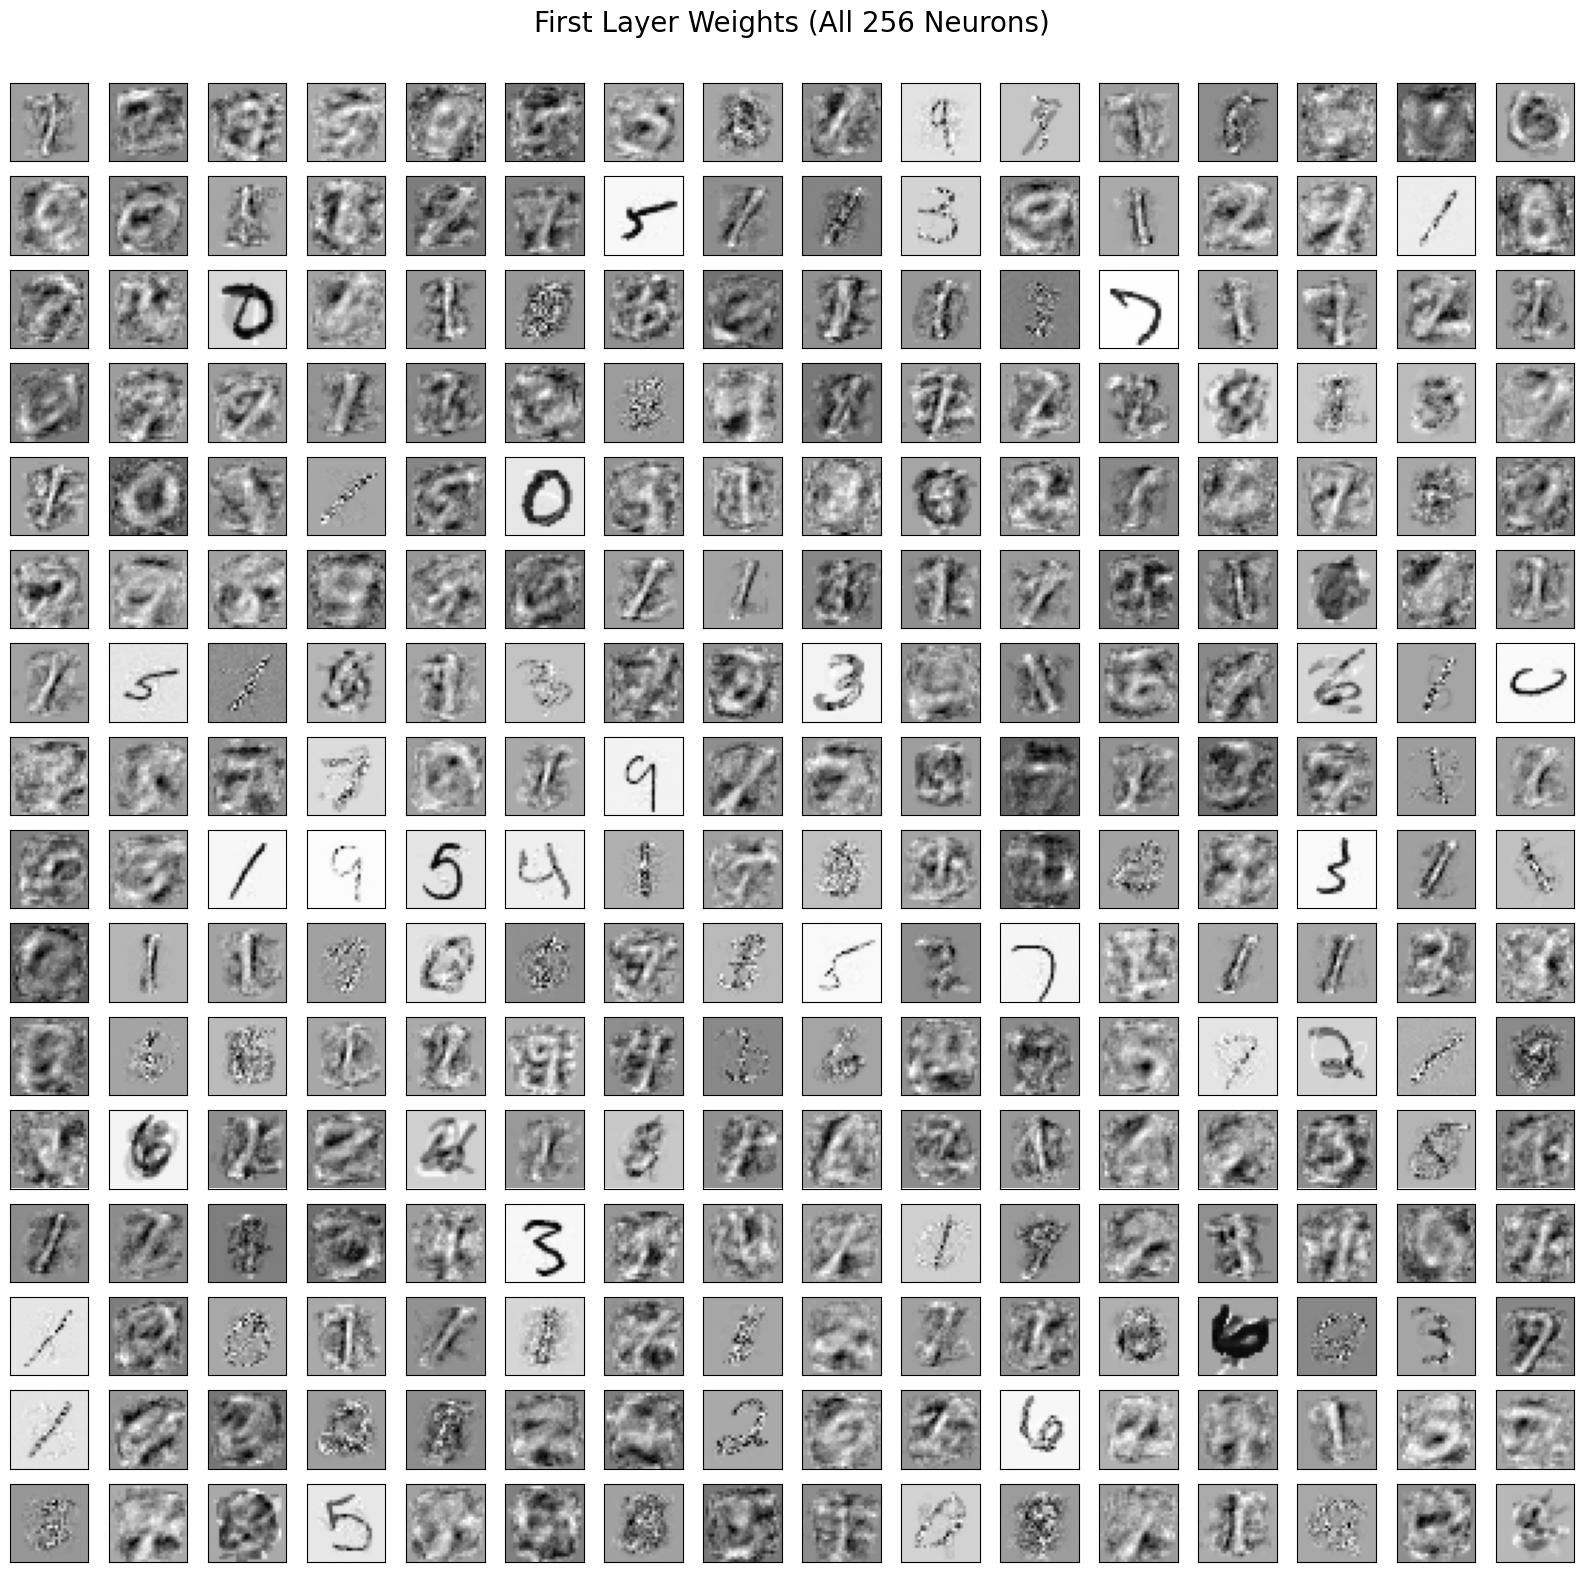

In [20]:
# 2. Get the weights from the first linear layer
first_layer_weights = model.encoder[0].weight.data.cpu()

print(f"First layer weights shape: {first_layer_weights.shape}")

# 3. Visualize all 256 neuron weights
num_to_show = 256
grid_size = int(num_to_show**0.5) # This will be 16

# --- ADJUSTED FIGSIZE ---
# Increased from (8, 8) to (16, 16) so the 16x16 grid is readable
fig, axes = plt.subplots(grid_size, grid_size, figsize=(16, 16))
fig.suptitle('First Layer Weights (All 256 Neurons)', fontsize=20)

for i, ax in enumerate(axes.flat):
    # The loop will run 256 times, and i will go from 0 to 255
    if i < num_to_show:
        # Reshape the i-th neuron's weights (784,) -> (28, 28)
        weight_image = first_layer_weights[i].reshape(28, 28)

        ax.imshow(weight_image, cmap='gray')

        # We can remove the title to make it cleaner
        # ax.set_title(f'Neuron {i}')
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout(rect=[0, 0, 1, 0.97]) # Adjusted rect for new title size

plt.savefig('first_layer_weights_ALL_256.png')
print("\nSaved 'first_layer_weights_ALL_256.png' to Colab files.")

plt.show()

In [ ]:
model_3 = training_run([28*28, 256, 128, 64, 32, 16], nn.ReLU , EPOCHS)

EPOCH 1:
   batch 1000 loss: 0.06299141158536077
   batch 2000 loss: 0.05007524051889777
   batch 3000 loss: 0.044303772853687404
   batch 4000 loss: 0.04038409102056176
   batch 5000 loss: 0.039064410558901724
   batch 6000 loss: 0.03738595664035529
   batch 7000 loss: 0.03658667504321784
   batch 8000 loss: 0.035676157139241695
   batch 9000 loss: 0.03471887653227895
   batch 10000 loss: 0.03445385152939707
   batch 11000 loss: 0.03326249369978905
   batch 12000 loss: 0.0325590280671604
   batch 13000 loss: 0.03193300410080701
   batch 14000 loss: 0.03133312452118844
   batch 15000 loss: 0.030873214351944626


HTML(value="<h3 style='text-align:center'>Interactive Autoencoder Reconstruction</h3>")

✓ Ready! Draw a digit to see the autoencoder reconstruction in real-time.


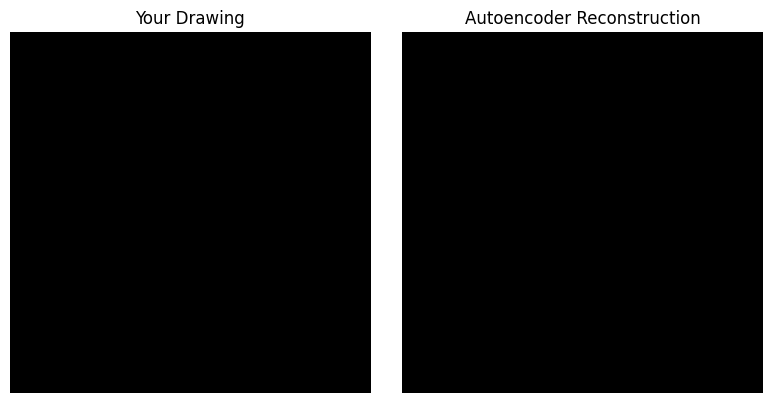

In [21]:
# --- Interactive Canvas with Real-time Autoencoder Reconstruction ---

import ipywidgets as widgets
from ipycanvas import Canvas
import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import display, clear_output
import time

# Create a 280x280 canvas
canvas_size = 280
cell_size = 10
canvas = Canvas(width=canvas_size, height=canvas_size, sync_image_data=True)
canvas.fill_style = 'black'
canvas.fill_rect(0, 0, canvas_size, canvas_size)
canvas.layout.width = '280px'
canvas.layout.height = '280px'

# Create output widget for matplotlib
fig_output = widgets.Output()

# Drawing state
drawing = False
last_update_time = 0
update_interval = 0.15

# Pre-create matplotlib figure
fig_2d, axes_2d = plt.subplots(1, 2, figsize=(8, 4))
ax_orig, ax_recon = axes_2d

img_plot = ax_orig.imshow(np.zeros((28, 28)), cmap='gray', vmin=0, vmax=1)
ax_orig.set_title("Your Drawing", fontsize=12)
ax_orig.axis('off')

recon_plot = ax_recon.imshow(np.zeros((28, 28)), cmap='gray', vmin=0, vmax=1)
ax_recon.set_title("Autoencoder Reconstruction", fontsize=12)
ax_recon.axis('off')

plt.tight_layout()

# Drawing functions
def draw_point(x, y):
    radius = 12
    canvas.fill_style = 'white'
    canvas.fill_circle(x, y, radius)

def handle_mouse_down(x, y):
    global drawing
    drawing = True
    draw_point(x, y)
    update_visualization()

def handle_mouse_up(x, y):
    global drawing
    drawing = False
    update_visualization()

def handle_mouse_move(x, y):
    global last_update_time
    if drawing:
        draw_point(x, y)
        current_time = time.time()
        if current_time - last_update_time > update_interval:
            last_update_time = current_time
            update_visualization()

canvas.on_mouse_down(handle_mouse_down)
canvas.on_mouse_up(handle_mouse_up)
canvas.on_mouse_move(handle_mouse_move)

# Main update function
def update_visualization():
    try:
        img_data = canvas.get_image_data(0, 0, canvas_size, canvas_size)
        if img_data is None or len(img_data) == 0:
            return

        # Process image
        img = np.asarray(img_data)[:, :, 0] / 255.0
        img_small = img.reshape(28, cell_size, 28, cell_size).mean(axis=(1, 3))
        img_tensor = torch.tensor(img_small, dtype=torch.float32).unsqueeze(0).to(device)
        img_tensor = img_tensor.view(-1, 28*28)

        with torch.no_grad():
            # Get reconstruction from model_2
            reconstruction = model_2(img_tensor)
            reconstruction_numpy = reconstruction.cpu().view(28, 28).numpy()

        # Update matplotlib plots
        img_plot.set_data(img_small)
        recon_plot.set_data(reconstruction_numpy)

        with fig_output:
            clear_output(wait=True)
            display(fig_2d)

    except Exception as e:
        pass  # Silently ignore canvas initialization errors

# Clear button
button = widgets.Button(
    description="Clear Canvas",
    button_style='warning',
    tooltip='Clear the drawing canvas'
)

def clear_canvas(b):
    canvas.fill_style = 'black'
    canvas.fill_rect(0, 0, canvas_size, canvas_size)
    update_visualization()

button.on_click(clear_canvas)

# Horizontal Layout
left_panel = widgets.VBox([
    widgets.HTML("<h4 style='margin:0'>Draw Here</h4>"),
    canvas,
    button
], layout=widgets.Layout(padding='10px'))

right_panel = widgets.VBox([
    widgets.HTML("<h4 style='margin:0'>Real-time View</h4>"),
    fig_output
], layout=widgets.Layout(padding='10px'))

main_layout = widgets.HBox(
    [left_panel, right_panel],
    layout=widgets.Layout(justify_content='center')
)

# Display UI
display(widgets.HTML("<h3 style='text-align:center'>Interactive Autoencoder Reconstruction</h3>"))
display(main_layout)

# Initial display
with fig_output:
    display(fig_2d)

print("✓ Ready! Draw a digit to see the autoencoder reconstruction in real-time.")